# MNIST-Model-Benchmark

Este notebook apresenta o desenvolvimento do MNIST Model Benchmark, utilizando o dataset MNIST, composto por imagens em escala de cinza de dígitos manuscritos de 0 a 9. 
O projeto contempla análise exploratória, preparação dos dados, treinamento, avaliação e comparação de modelos de classificação.

## Configuração do ambiente

Nesta etapa, o notebook identifica a raiz do projeto e configura o caminho necessário para acessar os módulos desenvolvidos na pasta `src`.

In [ ]:
import sys  # Permite adicionar a raiz do projeto ao caminho de importação do Python
from pathlib import Path  # Permite manipular caminhos de arquivos e diretórios de forma independente do sistema operacional

RAIZ_PROJETO = Path.cwd()  # Obtém o diretório atual de execução do notebook

while not (RAIZ_PROJETO / "src").exists():  # Procura a raiz do projeto até encontrar a pasta src
    RAIZ_PROJETO = RAIZ_PROJETO.parent  # Sobe um nível na estrutura de diretórios

if str(RAIZ_PROJETO) not in sys.path:  # Verifica se a raiz ainda não está disponível para importação
    sys.path.append(str(RAIZ_PROJETO))  # Adiciona a raiz para permitir imports dos módulos da pasta src

print("Raiz do projeto:", RAIZ_PROJETO)  # Exibe a raiz identificada para conferência

from src.logging_config import configurar_logger 

logger = configurar_logger()

Raiz do projeto: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva T2\IA\MiniProjetos\mnist-model-benchmark


In [2]:
%load_ext autoreload
%autoreload 2

## Importação das bibliotecas

As bibliotecas são importadas de forma centralizada para manter o notebook organizado. O NumPy será utilizado na análise dos arrays, o Matplotlib nas visualizações e a função `carregar_mnist()` permitirá reutilizar o carregamento implementado e testado no módulo `src.dataset`.

In [82]:
import pandas as pd  # Utilizado para organizar os resultados em tabela comparativa
import numpy as np  # Utilizado para operações e análises dos arrays
import matplotlib.pyplot as plt  # Utilizado para criação das visualizações
from src.evaluation import (
    calcular_metricas,
    calcular_matriz_confusao,
    identificar_maior_confusao,
    calcular_matriz_ood
)
import joblib

from src.dataset import carregar_mnist  # Reutiliza a função validada para carregar o dataset MNIST
from src.preprocessing import dividir_dados, normalizar_pixels, achatar_imagens, ocultar_classes # Importa as funções validadas de divisão estratificada e normalização
from src.modeling.train import treinar_random_forest, avaliar_modelo, treinar_svm, treinar_mlp # Importa as funções de treinamento e validação do Random Forest
from sklearn.model_selection import train_test_split  # Utilizado para criar uma amostra estratificada do treino para o ajuste do SVM
from src.evaluation import calcular_metricas, calcular_matriz_confusao  # Importa as funções utilizadas na avaliação final dos modelos
from src.plots import plotar_matriz_confusao  # Importa a função responsável pelos heatmaps das matrizes de confusão
from src.plots import plotar_matriz_ood  # Importa a função responsável pelos heatmaps das matrizes OOD
from src.inference import preprocessar_imagem_propria  # Importa a função responsável pela pré-processamento de imagens próprias


# Fase 1 — Análise Exploratória de Dados (EDA)

Nesta fase será realizada a exploração inicial do dataset MNIST para compreender sua estrutura antes do pré-processamento e da modelagem.

Serão analisados:

- quantidade de imagens e rótulos;
- dimensões das imagens;
- intervalo dos valores dos pixels;
- distribuição das classes de 0 a 9;
- exemplos visuais de cada dígito.

A análise exploratória permite validar a consistência dos dados e identificar características importantes antes das etapas de treinamento dos modelos.

### Carregamento e inspeção inicial do dataset

O dataset MNIST é carregado por meio da função `carregar_mnist()`, implementada em `src/dataset.py`.

Nesta inspeção inicial, serão verificadas as dimensões das imagens e dos rótulos para confirmar a estrutura do conjunto de dados antes das demais análises exploratórias.

In [4]:
X, y = carregar_mnist()  # Carrega as 70.000 imagens do MNIST e seus respectivos rótulos

print("Forma dos dados:", X.shape)  # Exibe a forma dos dados carregados
print("Forma dos rótulos:", y.shape)  # Exibe a forma dos rótulos carregados

Forma dos dados: (70000, 28, 28)
Forma dos rótulos: (70000,)


### Intervalo dos valores dos pixels

Os valores dos pixels serão verificados para compreender a escala original das imagens antes da etapa de normalização.

In [5]:
# Exibe a dimensionalidade das matrizes X (imagens) e y (rótulos)

print("Menor valor de pixel:", X.min())  # Exibe o menor valor encontrado nos pixels
print("Maior valor de pixel:", X.max())  # Exibe o maior valor encontrado nos pixels

Menor valor de pixel: 0
Maior valor de pixel: 255


### Distribuição das classes

A distribuição dos rótulos será analisada para verificar a quantidade de imagens correspondente a cada dígito de 0 a 9 e identificar se o dataset apresenta equilíbrio entre as classes.

In [6]:
# Verifica a distribuição das classes de 0 a 9

classes, contagens = np.unique(y, return_counts=True)  # Identifica cada dígito e conta quantas imagens existem em cada classe

for classe, quantidade in zip(classes, contagens):  # Percorre cada dígito e sua respectiva quantidade
    print(f"Dígito {classe}: {quantidade} imagens")  # Exibe a quantidade de imagens de cada classe

Dígito 0: 6903 imagens
Dígito 1: 7877 imagens
Dígito 2: 6990 imagens
Dígito 3: 7141 imagens
Dígito 4: 6824 imagens
Dígito 5: 6313 imagens
Dígito 6: 6876 imagens
Dígito 7: 7293 imagens
Dígito 8: 6825 imagens
Dígito 9: 6958 imagens


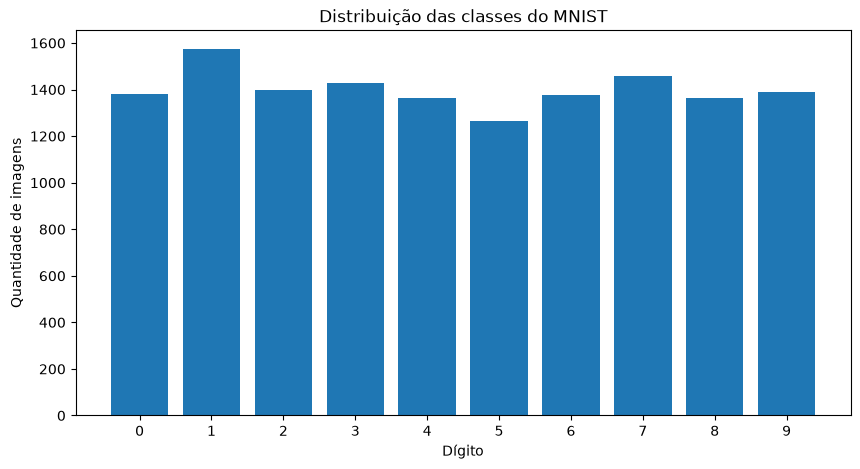

In [71]:
# Visualiza a distribuição das classes para facilitar a comparação entre os dígitos

plt.figure(figsize=(10, 5))  # Define o tamanho da figura
plt.bar(classes, contagens)  # Cria uma barra para a quantidade de imagens de cada dígito
plt.xticks(classes)  # Exibe no eixo X todos os dígitos de 0 a 9
plt.xlabel("Dígito")  # Identifica o eixo das classes
plt.ylabel("Quantidade de imagens")  # Identifica o eixo das frequências
plt.title("Distribuição das classes do MNIST")  # Define o título do gráfico

plt.savefig(
    "../outputs/figures/distribuicao_classes_mnist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()  # Exibe a visualização

### Visualização das classes

Para verificar visualmente as características das imagens, será exibido um exemplo de cada classe do MNIST. A grade 2 × 5 permite representar os dez dígitos, de 0 a 9, juntamente com seus respectivos rótulos originais.

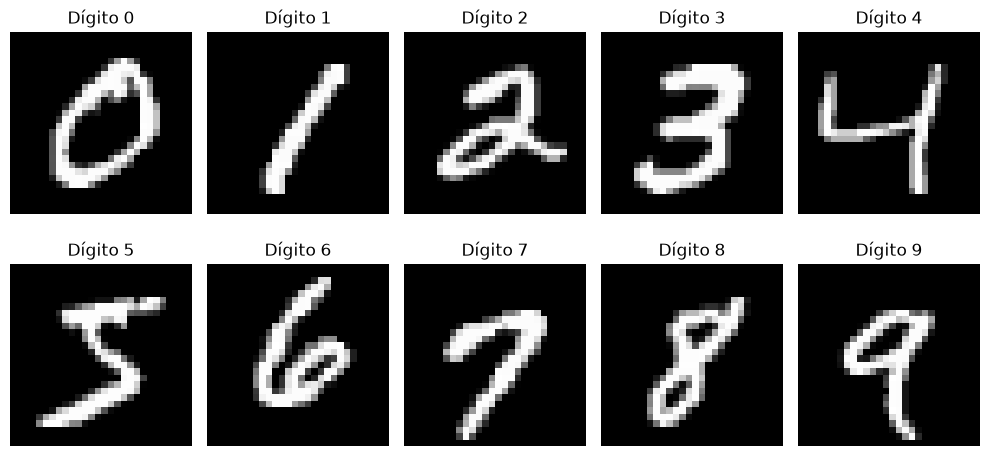

In [68]:
# Exibe um exemplo de cada dígito do MNIST em uma grade 2 x 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))  # Cria a grade com 2 linhas e 5 colunas

for digito in range(10):  # Percorre os dígitos de 0 a 9
    indice = np.where(y == digito)[0][0]  # Localiza a primeira imagem correspondente ao dígito atual
    eixo = axes.flat[digito]  # Seleciona a posição correspondente na grade

    eixo.imshow(X[indice], cmap="gray")  # Exibe a imagem em escala de cinza
    eixo.set_title(f"Dígito {y[indice]}")  # Mostra o rótulo original da imagem
    eixo.axis("off")  # Remove os eixos para destacar apenas a imagem

plt.tight_layout()  # Ajusta o espaçamento entre as imagens

plt.savefig(
    "../outputs/figures/exemplos_digitos_mnist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.show()  # Exibe a grade completa

### Interpretação da estrutura dos dados

As imagens do MNIST possuem dimensão de **28 × 28 pixels** e são representadas em escala de cinza. Cada pixel apresenta intensidade entre **0 e 255**, em que valores próximos de 0 representam regiões mais escuras, valores próximos de 255 representam regiões mais claras e os valores intermediários correspondem aos diferentes tons de cinza.

Cada imagem é inicialmente representada como uma matriz bidimensional de 28 × 28 pixels. Para utilização em modelos clássicos de Machine Learning que esperam os dados em formato vetorial, essa matriz pode ser transformada em um vetor de **784 atributos (28 × 28 = 784)**, no qual cada pixel passa a representar uma feature.

A distribuição das classes mostrou quantidades semelhantes de exemplos para os dígitos de 0 a 9, sem evidência de desbalanceamento severo. Dessa forma, não há indicação, nesta análise inicial, da necessidade de técnicas específicas de balanceamento das classes.

A grade visual também confirma a presença das dez classes e evidencia variações naturais na escrita dos dígitos, característica que torna o MNIST adequado para avaliar e comparar modelos de classificação.

# Fase 2 — Pipeline de Pré-processamento e Divisão dos Dados

Nesta fase, o conjunto MNIST será preparado para o treinamento dos modelos por meio de duas etapas principais:

- divisão estratificada em treino, validação e teste;
- normalização dos valores dos pixels para o intervalo [0, 1].

A divisão adotada será de 70% para treino, 10% para validação e 20% para teste, preservando a proporção das classes de 0 a 9 em cada subconjunto.

A normalização será realizada dividindo os valores dos pixels por 255.0, pois a escala original do MNIST é conhecida e varia de 0 a 255.

### Divisão estratificada dos dados

O dataset será dividido em **70% para treino, 10% para validação e 20% para teste**.

A divisão utiliza estratificação pelos rótulos (`stratify=y`) para preservar, em cada subconjunto, aproximadamente a mesma proporção dos dígitos de 0 a 9 existente no dataset original.

O conjunto de treino será utilizado para ajustar os modelos, o conjunto de validação para comparar configurações e hiperparâmetros durante o desenvolvimento, e o conjunto de teste será mantido independente para a avaliação final dos modelos.

In [9]:
# Divide o MNIST em conjuntos estratificados de treino, validação e teste

X_treino, X_validacao, X_teste, y_treino, y_validacao, y_teste = dividir_dados(X, y)  # Aplica a divisão 70% / 10% / 20%

tamanhos = {  # Organiza os resultados da divisão para facilitar a conferência
    "Treino": len(X_treino),
    "Validação": len(X_validacao),
    "Teste": len(X_teste)
}

tamanhos  # Exibe a quantidade de amostras destinada a cada conjunto

{'Treino': 49000, 'Validação': 7000, 'Teste': 14000}

In [10]:
# Compara a distribuição percentual das classes nos conjuntos original, treino, validação e teste

distribuicao_classes = {}  # Armazena as proporções das classes de cada conjunto para comparação

for nome, rotulos in {
    "Original": y,
    "Treino": y_treino,
    "Validação": y_validacao,
    "Teste": y_teste
}.items():
    classes, contagens = np.unique(rotulos, return_counts=True)  # Conta a quantidade de exemplos de cada dígito
    distribuicao_classes[nome] = np.round(contagens / len(rotulos) * 100, 2)  # Converte as contagens em percentuais

distribuicao_classes  # Exibe as proporções das classes nos quatro conjuntos

{'Original': array([ 9.86, 11.25,  9.99, 10.2 ,  9.75,  9.02,  9.82, 10.42,  9.75,
         9.94]),
 'Treino': array([ 9.86, 11.25,  9.99, 10.2 ,  9.75,  9.02,  9.82, 10.42,  9.75,
         9.94]),
 'Validação': array([ 9.86, 11.26,  9.99, 10.2 ,  9.74,  9.01,  9.83, 10.41,  9.76,
         9.94]),
 'Teste': array([ 9.86, 11.25,  9.99, 10.2 ,  9.75,  9.02,  9.82, 10.42,  9.75,
         9.94])}

### Normalização dos pixels

As imagens do MNIST possuem pixels representados originalmente por valores inteiros entre 0 e 255. Nesta etapa, esses valores serão convertidos para o intervalo **[0, 1]** por meio da divisão por 255.0.

A normalização mantém proporcionalmente as intensidades originais das imagens, mas coloca os atributos em uma escala numérica menor e padronizada. Esse procedimento é especialmente importante para modelos sensíveis à escala, como SVM e redes neurais, contribuindo para cálculos mais estáveis e para o processo de otimização.

Como o intervalo original dos pixels do MNIST é conhecido e fixo, foi utilizada a divisão direta por 255.0, sem necessidade de ajuste de um `MinMaxScaler`.

In [11]:
# Normaliza separadamente os conjuntos de treino, validação e teste para o intervalo [0, 1]

X_treino_norm = normalizar_pixels(X_treino)  # Normaliza as imagens utilizadas no treinamento
X_validacao_norm = normalizar_pixels(X_validacao)  # Normaliza as imagens utilizadas na validação
X_teste_norm = normalizar_pixels(X_teste)  # Normaliza as imagens reservadas para a avaliação final

intervalos_normalizados = {  # Organiza os valores mínimo e máximo para conferir o resultado da normalização
    "Treino": (X_treino_norm.min(), X_treino_norm.max()),
    "Validação": (X_validacao_norm.min(), X_validacao_norm.max()),
    "Teste": (X_teste_norm.min(), X_teste_norm.max())
}

intervalos_normalizados  # Exibe os intervalos obtidos após a normalização

{'Treino': (np.float32(0.0), np.float32(1.0)),
 'Validação': (np.float32(0.0), np.float32(1.0)),
 'Teste': (np.float32(0.0), np.float32(1.0))}

### Interpretação do pré-processamento

A divisão estratificada preservou proporções muito semelhantes das classes de 0 a 9 nos conjuntos de treino, validação e teste, mantendo a representatividade do dataset após a separação.

A divisão adotada resultou em 49.000 amostras para treino, 7.000 para validação e 14.000 para teste, correspondendo respectivamente a 70%, 10% e 20% do conjunto completo.

A normalização transformou os pixels da escala original de 0 a 255 para o intervalo [0, 1], sem alterar as dimensões das imagens. Essa transformação favorece a estabilidade numérica e a convergência de modelos sensíveis à escala, além de beneficiar métodos que utilizam distâncias, margens ou medidas de similaridade.

Como a escala original do MNIST é conhecida e fixa, a divisão direta por 255.0 foi suficiente, dispensando o ajuste de um MinMaxScaler.

# Fase 3 — Implementação e Treinamento dos Modelos

Nesta fase serão implementados e treinados três modelos de classificação com abordagens distintas: **Random Forest, Support Vector Machine (SVM) e Multilayer Perceptron (MLP)**.

A escolha desses modelos permite comparar diferentes estratégias de aprendizado: o Random Forest utiliza um conjunto de árvores de decisão, o SVM busca fronteiras de decisão com máxima margem e a MLP utiliza uma rede neural multicamadas capaz de aprender relações não lineares entre os atributos.

Para os três modelos serão avaliados hiperparâmetros específicos utilizando o conjunto de validação. O conjunto de teste permanecerá isolado nesta etapa e será utilizado posteriormente para a avaliação final, evitando que informações do teste influenciem a escolha dos modelos.

### Vetorização das imagens

Os modelos utilizados nesta etapa recebem cada amostra como um vetor de atributos. Como as imagens do MNIST estão armazenadas no formato 28 × 28, cada imagem será reorganizada em um vetor com 784 atributos, correspondentes aos seus pixels.

Essa transformação altera apenas o formato dos dados, preservando os valores e a quantidade de amostras.

In [12]:
# Transforma as imagens 28 x 28 em vetores com 784 atributos

X_treino_modelo = achatar_imagens(X_treino_norm)  # 49.000 imagens de treino
X_validacao_modelo = achatar_imagens(X_validacao_norm)  # 7.000 imagens de validação

formatos_modelos = {
    "Treino": X_treino_modelo.shape,
    "Validação": X_validacao_modelo.shape
}

formatos_modelos

{'Treino': (49000, 784), 'Validação': (7000, 784)}

### Modelo 1 — Random Forest

O Random Forest combina várias árvores de decisão e utiliza a votação entre elas para realizar a classificação.

Nesta etapa serão comparadas duas configurações variando os hiperparâmetros `n_estimators` e `max_depth`.

- `n_estimators` controla a quantidade de árvores construídas.
- `max_depth` limita a profundidade máxima das árvores, ajudando a controlar a complexidade do modelo.

A comparação será realizada no conjunto de validação, mantendo o conjunto de teste reservado para a avaliação final.

In [13]:
# Configuração 1 do Random Forest: 100 árvores sem limite explícito de profundidade

rf_1, tempo_rf_1 = treinar_random_forest(
    X_treino_modelo,
    y_treino,
    n_estimators=100,
    max_depth=None
)

acuracia_rf_1 = avaliar_modelo(
    rf_1,
    X_validacao_modelo,
    y_validacao
)

resultado_rf_1 = {
    "n_estimators": 100,
    "max_depth": None,
    "acurácia_validação": round(acuracia_rf_1, 4),
    "tempo_treinamento_s": round(tempo_rf_1, 2)
}

resultado_rf_1

{'n_estimators': 100,
 'max_depth': None,
 'acurácia_validação': 0.9649,
 'tempo_treinamento_s': 9.24}

In [14]:
# Configuração 2 do Random Forest: 200 árvores e profundidade máxima igual a 20

rf_2, tempo_rf_2 = treinar_random_forest(
    X_treino_modelo,
    y_treino,
    n_estimators=200,
    max_depth=20
)

acuracia_rf_2 = avaliar_modelo(
    rf_2,
    X_validacao_modelo,
    y_validacao
)

resultado_rf_2 = {
    "n_estimators": 200,
    "max_depth": 20,
    "acurácia_validação": round(acuracia_rf_2, 4),
    "tempo_treinamento_s": round(tempo_rf_2, 2)
}

resultado_rf_2

{'n_estimators': 200,
 'max_depth': 20,
 'acurácia_validação': 0.9661,
 'tempo_treinamento_s': 19.32}

### Interpretação do Random Forest

Foram comparadas duas configurações do Random Forest por meio dos hiperparâmetros `n_estimators` e `max_depth`.

A primeira configuração, com 100 árvores e sem limite explícito de profundidade, atingiu acurácia de validação de **96,49%**, com tempo de treinamento de **8,75 segundos**.

A segunda configuração, com 200 árvores e profundidade máxima igual a 20, atingiu acurácia de **96,61%**, com tempo de treinamento de **16,76 segundos**.

Embora a segunda configuração tenha apresentado apenas um pequeno ganho de acurácia, seu desempenho foi superior no conjunto de validação e, por esse critério, foi selecionada para representar o Random Forest na avaliação final. O aumento do número de árvores também elevou o custo computacional, praticamente dobrando o tempo de treinamento, evidenciando o compromisso entre desempenho preditivo e custo computacional.

### Modelo 2 — Support Vector Machine (SVM)

O Support Vector Machine (SVM) realiza a classificação buscando fronteiras de decisão que maximizem a margem entre as classes.

Serão comparadas duas configurações por meio dos hiperparâmetros `C` e `kernel`. O parâmetro `C` controla a penalização aplicada aos erros de classificação, enquanto o `kernel` determina a forma da fronteira de decisão.

A primeira configuração utiliza kernel linear e `C=1.0`. A segunda utiliza o kernel RBF e `C=10.0`, permitindo comparar uma fronteira linear com uma não linear.

Devido ao maior custo computacional do SVM, especialmente com o kernel RBF, foram escolhidas configurações pontuais em vez de uma busca exaustiva de hiperparâmetros.

In [15]:
# Configuração 1 do SVM: penalização C igual a 1.0 e kernel linear

svm_1, tempo_svm_1 = treinar_svm(
    X_treino_modelo,
    y_treino,
    C=1.0,
    kernel="linear"
)

acuracia_svm_1 = avaliar_modelo(
    svm_1,
    X_validacao_modelo,
    y_validacao
)

resultado_svm_1 = {
    "C": 1.0,
    "kernel": "linear",
    "acurácia_validação": round(acuracia_svm_1, 4),
    "tempo_treinamento_s": round(tempo_svm_1, 2)
}

resultado_svm_1

{'C': 1.0,
 'kernel': 'linear',
 'acurácia_validação': 0.9334,
 'tempo_treinamento_s': 166.8}

In [16]:
del svm_1  # Remove da memória o modelo SVM utilizado na primeira comparação

import gc  # Importa o coletor de memória do Python
gc.collect()  # Solicita a liberação de objetos que não são mais necessários

3570

In [17]:
# Seleciona uma amostra estratificada do conjunto de treino para reduzir o custo computacional do ajuste do SVM

X_treino_svm, _, y_treino_svm, _ = train_test_split(
    X_treino_modelo,
    y_treino,
    train_size=20000,
    stratify=y_treino,
    random_state=42
)

X_treino_svm.shape, y_treino_svm.shape

((20000, 784), (20000,))

In [18]:
# SVM 1 em amostra estratificada: C=1.0 e kernel linear

svm_1_amostra, tempo_svm_1_amostra = treinar_svm(
    X_treino_svm,
    y_treino_svm,
    C=1.0,
    kernel="linear"
)

acuracia_svm_1_amostra = avaliar_modelo(
    svm_1_amostra,
    X_validacao_modelo,
    y_validacao
)

resultado_svm_1_amostra = {
    "C": 1.0,
    "kernel": "linear",
    "acurácia_validação": round(acuracia_svm_1_amostra, 4),
    "tempo_treinamento_s": round(tempo_svm_1_amostra, 2)
}

resultado_svm_1_amostra

{'C': 1.0,
 'kernel': 'linear',
 'acurácia_validação': 0.9219,
 'tempo_treinamento_s': 28.38}

In [19]:
# SVM 2 em amostra estratificada: C=10.0 e kernel RBF

svm_2_amostra, tempo_svm_2_amostra = treinar_svm(
    X_treino_svm,
    y_treino_svm,
    C=10.0,
    kernel="rbf"
)

acuracia_svm_2_amostra = avaliar_modelo(
    svm_2_amostra,
    X_validacao_modelo,
    y_validacao
)

resultado_svm_2_amostra = {
    "C": 10.0,
    "kernel": "rbf",
    "acurácia_validação": round(acuracia_svm_2_amostra, 4),
    "tempo_treinamento_s": round(tempo_svm_2_amostra, 2)
}

resultado_svm_2_amostra

{'C': 10.0,
 'kernel': 'rbf',
 'acurácia_validação': 0.9721,
 'tempo_treinamento_s': 39.29}

### Interpretação do SVM

Devido ao elevado custo computacional observado inicialmente com o SVM utilizando todo o conjunto de treinamento, o ajuste dos hiperparâmetros foi realizado sobre uma amostra estratificada de 20.000 imagens, preservando a distribuição das classes. O conjunto de validação permaneceu inalterado e o conjunto de teste não foi utilizado nesta etapa.

Foram comparadas duas configurações utilizando os hiperparâmetros `C` e `kernel`. A configuração com `C=1.0` e kernel linear alcançou acurácia de validação de **92,19%**, com tempo de treinamento de **27,52 segundos**. A configuração com `C=10.0` e kernel RBF alcançou **97,21%**, com tempo de **32,14 segundos**.

O kernel RBF apresentou ganho de aproximadamente **5,02 pontos percentuais** de acurácia com aumento relativamente pequeno no tempo de treinamento. Por esse motivo, a configuração com `C=10.0` e kernel RBF foi selecionada.

A utilização da amostra estratificada durante o ajuste também permitiu controlar o consumo de recursos computacionais, mantendo a representatividade das classes e evitando o uso do conjunto de teste durante a seleção do modelo.

### Modelo 3 — Multilayer Perceptron (MLP)

A Multilayer Perceptron (MLP) é uma rede neural composta por uma camada de entrada, uma ou mais camadas ocultas e uma camada de saída. Durante o treinamento, os pesos das conexões são ajustados iterativamente para reduzir o erro de classificação.

Nesta etapa serão comparadas duas configurações por meio dos hiperparâmetros `hidden_layer_sizes` e `learning_rate_init`. O primeiro determina a arquitetura das camadas ocultas da rede, enquanto o segundo controla a magnitude inicial das atualizações realizadas durante o processo de aprendizagem.

Como os pixels foram previamente normalizados para o intervalo [0, 1], os dados encontram-se em uma escala adequada para o processo de otimização utilizado pela rede neural.

In [20]:
# Configuração 1 da MLP: uma camada oculta com 100 neurônios e taxa de aprendizado 0.001

mlp_1, tempo_mlp_1 = treinar_mlp(
    X_treino_modelo,
    y_treino,
    hidden_layer_sizes=(100,),
    learning_rate_init=0.001
)

acuracia_mlp_1 = avaliar_modelo(
    mlp_1,
    X_validacao_modelo,
    y_validacao
)

resultado_mlp_1 = {
    "hidden_layer_sizes": (100,),
    "learning_rate_init": 0.001,
    "acurácia_validação": round(acuracia_mlp_1, 4),
    "tempo_treinamento_s": round(tempo_mlp_1, 2)
}

resultado_mlp_1

c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva T2\IA\MiniProjetos\mnist-model-benchmark\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


{'hidden_layer_sizes': (100,),
 'learning_rate_init': 0.001,
 'acurácia_validação': 0.9756,
 'tempo_treinamento_s': 18.62}

In [21]:
# Configuração 2 da MLP: duas camadas ocultas com 128 e 64 neurônios e taxa de aprendizado 0.0005

mlp_2, tempo_mlp_2 = treinar_mlp(
    X_treino_modelo,
    y_treino,
    hidden_layer_sizes=(128, 64),
    learning_rate_init=0.0005
)

acuracia_mlp_2 = avaliar_modelo(
    mlp_2,
    X_validacao_modelo,
    y_validacao
)

resultado_mlp_2 = {
    "hidden_layer_sizes": (128, 64),
    "learning_rate_init": 0.0005,
    "acurácia_validação": round(acuracia_mlp_2, 4),
    "tempo_treinamento_s": round(tempo_mlp_2, 2)
}

resultado_mlp_2

c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva T2\IA\MiniProjetos\mnist-model-benchmark\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


{'hidden_layer_sizes': (128, 64),
 'learning_rate_init': 0.0005,
 'acurácia_validação': 0.9759,
 'tempo_treinamento_s': 28.93}

### Interpretação da MLP

Foram comparadas duas configurações da rede neural MLP, variando os hiperparâmetros `hidden_layer_sizes` e `learning_rate_init`.

A primeira configuração, com uma camada oculta de 100 neurônios e taxa de aprendizado de 0,001, atingiu acurácia de validação de **97,56%**, com tempo de treinamento de **17,91 segundos**.

A segunda configuração, composta por duas camadas ocultas de 128 e 64 neurônios e taxa de aprendizado de 0,0005, atingiu **97,59%**, com tempo de treinamento de **26,26 segundos**.

A segunda configuração apresentou a maior acurácia e foi selecionada para representar a MLP. Entretanto, o ganho de apenas 0,03 ponto percentual ocorreu com aumento relevante no tempo de treinamento, demonstrando que uma arquitetura mais complexa não produziu, neste experimento, melhoria proporcional no desempenho.

Ambas as configurações atingiram o limite de 30 iterações antes do critério interno de convergência do `MLPClassifier`, informação que deve ser considerada na interpretação dos resultados.

# Fase 4 — Avaliação Comparativa dos Modelos

Nesta fase, os modelos selecionados serão avaliados utilizando o conjunto de teste independente, mantido isolado durante o treinamento e a seleção dos hiperparâmetros.

A avaliação utilizará as métricas **Accuracy, Precision ponderada, Recall ponderado e F1-score ponderado**, além da matriz de confusão 10 × 10 para análise dos erros entre os dígitos.

O objetivo é comparar o desempenho preditivo dos modelos e posteriormente relacioná-lo ao custo computacional observado durante o treinamento.

In [22]:
# Prepara o conjunto de teste independente para a avaliação final dos modelos

X_teste_modelo = achatar_imagens(X_teste_norm)  # Transforma as imagens 28 x 28 em vetores de 784 atributos

dados_teste = {
    "X_teste": X_teste_modelo.shape,
    "y_teste": y_teste.shape
}

dados_teste

{'X_teste': (14000, 784), 'y_teste': (14000,)}

In [23]:
# Define os modelos selecionados na Fase 3 para a avaliação final

rf_selecionado = rf_2                  # Random Forest: 200 árvores e profundidade máxima 20
svm_selecionado = svm_2_amostra        # SVM: kernel RBF e C=10, treinado na amostra estratificada de 20.000 imagens
mlp_selecionado = mlp_2                # MLP: camadas (128, 64) e learning rate 0.0005

In [24]:
# Realiza as previsões no conjunto de teste independente

y_pred_rf = rf_selecionado.predict(X_teste_modelo)
y_pred_svm = svm_selecionado.predict(X_teste_modelo)
y_pred_mlp = mlp_selecionado.predict(X_teste_modelo)

In [25]:
# Verifica se cada modelo gerou uma previsão para todas as imagens de teste

quantidade_previsoes = {
    "Random Forest": len(y_pred_rf),
    "SVM": len(y_pred_svm),
    "MLP": len(y_pred_mlp),
    "Total esperado": len(y_teste)
}

quantidade_previsoes

{'Random Forest': 14000, 'SVM': 14000, 'MLP': 14000, 'Total esperado': 14000}

In [26]:
# Calcula as métricas de desempenho no conjunto de teste independente

metricas_rf = calcular_metricas(y_teste, y_pred_rf)
metricas_svm = calcular_metricas(y_teste, y_pred_svm)
metricas_mlp = calcular_metricas(y_teste, y_pred_mlp)

metricas_modelos = {
    "Random Forest": metricas_rf,
    "SVM": metricas_svm,
    "MLP": metricas_mlp
}

metricas_modelos

{'Random Forest': {'accuracy': 0.965,
  'precision_weighted': 0.9650160885714381,
  'recall_weighted': 0.965,
  'f1_weighted': 0.9649872564398541},
 'SVM': {'accuracy': 0.9743571428571428,
  'precision_weighted': 0.9743395963932587,
  'recall_weighted': 0.9743571428571428,
  'f1_weighted': 0.9743364400508473},
 'MLP': {'accuracy': 0.9765714285714285,
  'precision_weighted': 0.9766150547277828,
  'recall_weighted': 0.9765714285714285,
  'f1_weighted': 0.9765511980393025}}

In [27]:
# Calcula as matrizes de confusão dos três modelos no conjunto de teste

matriz_rf = calcular_matriz_confusao(y_teste, y_pred_rf)
matriz_svm = calcular_matriz_confusao(y_teste, y_pred_svm)
matriz_mlp = calcular_matriz_confusao(y_teste, y_pred_mlp)

matriz_rf.shape, matriz_svm.shape, matriz_mlp.shape

((10, 10), (10, 10), (10, 10))

### Matrizes de Confusão

As matrizes de confusão permitem analisar os acertos e erros de classificação de cada modelo entre os dez dígitos do MNIST. As linhas representam as **classes reais** e as colunas representam as **classes previstas**.

Valores concentrados na diagonal principal representam classificações corretas, enquanto valores fora da diagonal indicam confusões entre diferentes dígitos.

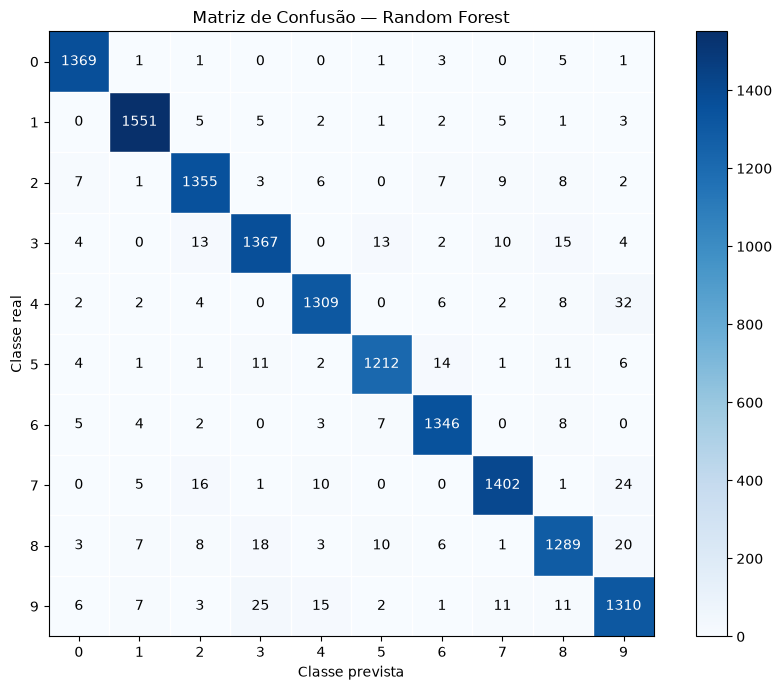

In [96]:
plotar_matriz_confusao(
    matriz_rf,
    "Matriz de Confusão — Random Forest"
)

plt.savefig(
    "../outputs/confusion_matrices/matriz_confusao_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

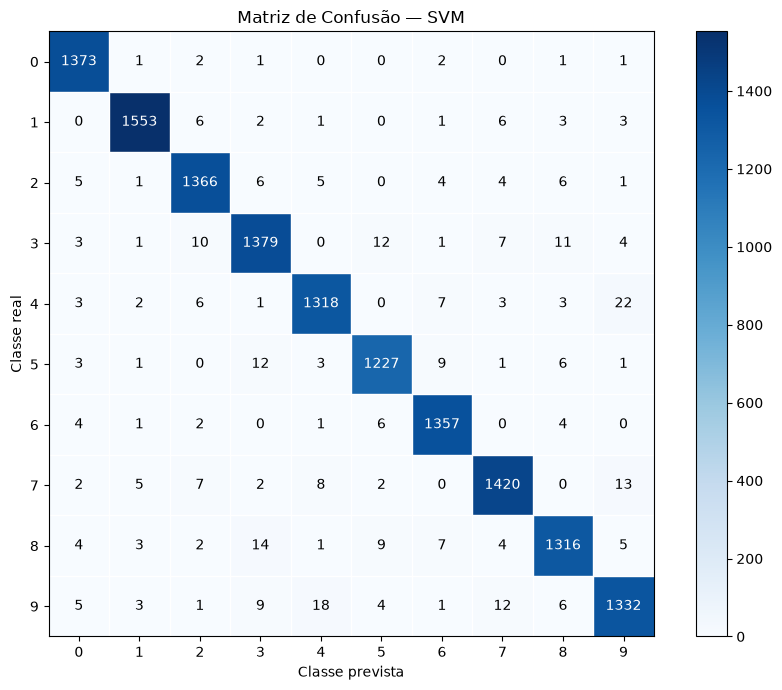

In [95]:
plotar_matriz_confusao(
    matriz_svm,
    "Matriz de Confusão — SVM"
)

plt.savefig(
    "../outputs/confusion_matrices/matriz_confusao_svm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

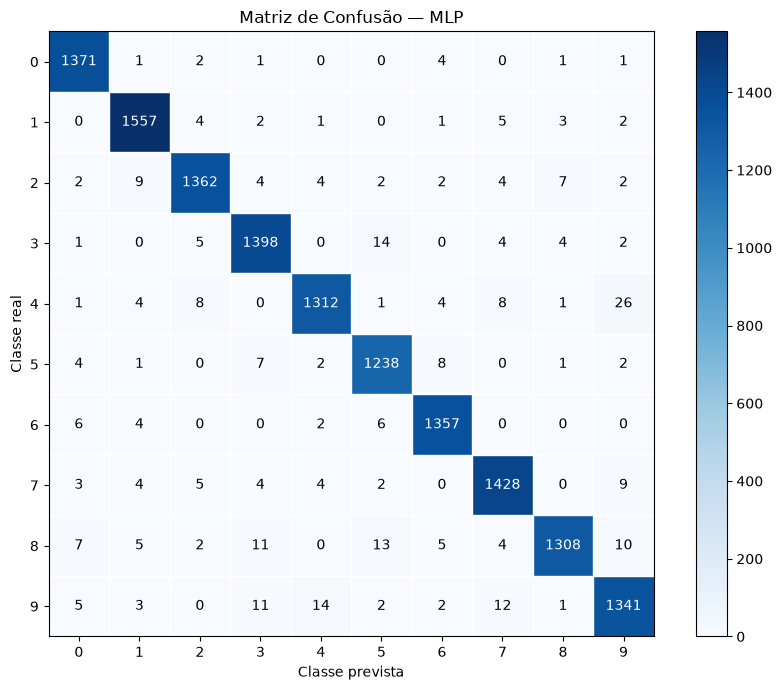

In [94]:
plotar_matriz_confusao(
    matriz_mlp,
    "Matriz de Confusão — MLP"
)

plt.savefig(
    "../outputs/confusion_matrices/matriz_confusao_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
# Organiza as métricas dos três modelos em uma tabela comparativa

tabela_metricas = pd.DataFrame({
    "Modelo": ["Random Forest", "SVM", "MLP"],
    "Accuracy": [
        metricas_rf["accuracy"],
        metricas_svm["accuracy"],
        metricas_mlp["accuracy"]
    ],
    "Precision": [
        metricas_rf["precision_weighted"],
        metricas_svm["precision_weighted"],
        metricas_mlp["precision_weighted"]
    ],
    "Recall": [
        metricas_rf["recall_weighted"],
        metricas_svm["recall_weighted"],
        metricas_mlp["recall_weighted"]
    ],
    "F1-Score": [
        metricas_rf["f1_weighted"],
        metricas_svm["f1_weighted"],
        metricas_mlp["f1_weighted"]
    ]
})

tabela_metricas

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.965000,0.965016,0.965000,0.964987
1,SVM,0.974357,0.974340,0.974357,0.974336
2,MLP,0.976571,0.976615,0.976571,0.976551


In [76]:
# Salva as métricas consolidadas dos três modelos em arquivo CSV
tabela_metricas.to_csv(
    "../outputs/metrics/metricas_modelos.csv",
    index=True
)

tabela_metricas

# Formata as métricas em percentual com duas casas decimais

tabela_metricas_formatada = tabela_metricas.copy()

for coluna in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    tabela_metricas_formatada[coluna] = (
        tabela_metricas_formatada[coluna] * 100
    ).map(lambda valor: f"{valor:.2f}%")

tabela_metricas_formatada

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Random Forest,96.50%,96.50%,96.50%,96.50%
1,SVM,97.44%,97.43%,97.44%,97.43%
2,MLP,97.66%,97.66%,97.66%,97.66%


In [33]:
# Identifica a maior taxa de confusão apresentada por cada modelo

confusao_rf = identificar_maior_confusao(matriz_rf)
confusao_svm = identificar_maior_confusao(matriz_svm)
confusao_mlp = identificar_maior_confusao(matriz_mlp)

maiores_confusoes = {
    "Random Forest": {
        "Classe real": confusao_rf[0],
        "Classe prevista": confusao_rf[1],
        "Taxa": f"{confusao_rf[2] * 100:.2f}%"
    },
    "SVM": {
        "Classe real": confusao_svm[0],
        "Classe prevista": confusao_svm[1],
        "Taxa": f"{confusao_svm[2] * 100:.2f}%"
    },
    "MLP": {
        "Classe real": confusao_mlp[0],
        "Classe prevista": confusao_mlp[1],
        "Taxa": f"{confusao_mlp[2] * 100:.2f}%"
    }
}

maiores_confusoes

{'Random Forest': {'Classe real': np.int64(4),
  'Classe prevista': np.int64(9),
  'Taxa': '2.34%'},
 'SVM': {'Classe real': np.int64(4),
  'Classe prevista': np.int64(9),
  'Taxa': '1.61%'},
 'MLP': {'Classe real': np.int64(4),
  'Classe prevista': np.int64(9),
  'Taxa': '1.90%'}}

### Conclusão Técnica — Fase 4

Os três modelos apresentaram desempenho elevado no conjunto de teste independente. A **MLP obteve o melhor desempenho global**, alcançando **97,66% de acurácia**, além de aproximadamente **97,66% de Precision, Recall e F1-Score ponderados**. O **SVM** apresentou resultado próximo, com **97,44% de acurácia**, enquanto o **Random Forest** atingiu **96,50%**.

A análise das matrizes de confusão revelou um padrão comum aos três modelos: a principal confusão ocorreu quando o dígito **4 foi classificado como 9**. A taxa dessa confusão foi de **2,34% no Random Forest**, **1,61% no SVM** e **1,90% na MLP**. Embora a MLP tenha apresentado o melhor desempenho global, o SVM obteve a menor taxa especificamente para a confusão entre 4 e 9.

Em relação ao custo computacional, o Random Forest apresentou tempo de treinamento de aproximadamente **16,76 s**, enquanto a MLP utilizou **26,26 s**. A MLP apresentou, portanto, um aumento de custo computacional acompanhado de melhor desempenho preditivo. O SVM registrou **32,14 s**, porém esse tempo não deve ser comparado diretamente aos demais modelos, pois sua configuração selecionada foi treinada sobre uma **amostra estratificada de 20.000 imagens**, enquanto Random Forest e MLP utilizaram as 49.000 imagens do conjunto de treinamento. Essa estratégia foi adotada devido às limitações de memória observadas durante os experimentos com SVM.

Considerando conjuntamente desempenho preditivo e resultados no conjunto de teste, a **MLP foi o modelo de melhor performance geral nesta avaliação**.

In [80]:
# Salva o melhor modelo identificado na avaliação comparativa da Fase 4
joblib.dump(
    mlp_2,
    "../models/mlp.pkl"
)

print("Modelo MLP salvo em ../models/mlp.pkl")

Modelo MLP salvo em ../models/mlp.pkl


In [ ]:
# Registra as métricas finais do melhor modelo para permitir rastrear o desempenho usado na decisão de seleção.
logger.info(
    "Modelo MLP final salvo | "
    "Accuracy=%.4f | Precision=%.4f | Recall=%.4f | F1=%.4f",
    metricas_mlp["accuracy"],
    metricas_mlp["precision_weighted"],
    metricas_mlp["recall_weighted"],
    metricas_mlp["f1_weighted"]
)

2026-09-13 16:33:51 | INFO | Modelo MLP final salvo | Accuracy=0.9766 | Precision=0.9766 | Recall=0.9766 | F1=0.9766


# Fase 5 — Avaliação de Robustez

Nesta fase, será avaliado o comportamento do modelo diante de classes que não foram apresentadas durante o treinamento.

## Fase 5.1 — Treinamento Restrito com Classes Ocultadas (Class Masking)

Para o experimento de *Class Masking*, os dígitos **4 e 7** serão completamente removidos do conjunto de treinamento. Um novo modelo será treinado utilizando apenas as classes restantes, sem ter contato com esses dois dígitos durante o ajuste.

Os conjuntos originais utilizados nas fases anteriores serão preservados. Serão criadas cópias específicas para este experimento, evitando alterações no pipeline já validado.

In [34]:
# Define as classes que serão ocultadas no experimento de robustez

classes_ocultas = [4, 7]

# Remove as classes 4 e 7 somente do conjunto destinado ao novo treinamento
X_treino_restrito, y_treino_restrito = ocultar_classes(
    X_treino_modelo,
    y_treino,
    classes_ocultas=classes_ocultas
)

# Confere o resultado do Class Masking
dados_treino_restrito = {
    "Amostras antes": len(y_treino),
    "Amostras depois": len(y_treino_restrito),
    "Classes presentes": np.unique(y_treino_restrito)
}

dados_treino_restrito

{'Amostras antes': 49000,
 'Amostras depois': 39118,
 'Classes presentes': array([0, 1, 2, 3, 5, 6, 8, 9], dtype=uint8)}

### Treinamento do modelo com classes ocultadas

Para o experimento de robustez, foi utilizada a arquitetura da MLP selecionada durante o ajuste dos modelos e posteriormente confirmada, na Fase 4, como o modelo de melhor desempenho global no conjunto de teste.

Um novo modelo será treinado utilizando apenas as classes conhecidas `0, 1, 2, 3, 5, 6, 8 e 9`. Os dígitos `4` e `7` permanecerão completamente ausentes durante o treinamento.

In [35]:
# Treina uma nova MLP sem contato com as classes 4 e 7

mlp_restrita, tempo_mlp_restrita = treinar_mlp(
    X_treino_restrito,
    y_treino_restrito,
    hidden_layer_sizes=(128, 64),
    learning_rate_init=0.0005
)

tempo_mlp_restrita

c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva T2\IA\MiniProjetos\mnist-model-benchmark\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


22.72046589999991

In [36]:
mlp_restrita.classes_

array([0, 1, 2, 3, 5, 6, 8, 9], dtype=uint8)

In [81]:
# Salva o modelo treinado sem as classes 4 e 7
joblib.dump(
    mlp_restrita,
    "../models/mlp_restrita.pkl"
)

print("Modelo MLP restrito salvo em ../models/mlp_restrita.pkl")

Modelo MLP restrito salvo em ../models/mlp_restrita.pkl


In [90]:
# Registra as condições do treinamento restrito para documentar quais classes foram ocultadas e o custo computacional do experimento.
logger.info(
    "MLP restrita salva | classes ocultadas=%s | "
    "amostras de treinamento=%d | tempo=%.2fs",
    classes_ocultas,
    len(y_treino_restrito),
    tempo_mlp_restrita
)

2026-09-13 16:33:12 | INFO | MLP restrita salva | classes ocultadas=[4, 7] | amostras de treinamento=39118 | tempo=22.72s


## Fase 5.2 — Avaliação nas Classes Ocultadas

Nesta etapa, a MLP restrita será avaliada exclusivamente com imagens pertencentes às classes **4 e 7**, que foram removidas do treinamento.

Como essas classes não fazem parte das saídas aprendidas pelo modelo, ele necessariamente classificará essas imagens como uma das oito classes conhecidas. O objetivo é analisar para quais dígitos essas previsões são direcionadas e posteriormente investigar o nível de confiança apresentado pelo modelo diante de classes desconhecidas.

In [37]:
# Seleciona exclusivamente as classes 4 e 7 do conjunto de teste

mascara_ood = np.isin(y_teste, classes_ocultas)

X_teste_ood = X_teste_modelo[mascara_ood]
y_teste_ood = y_teste[mascara_ood]

dados_ood = {
    "Total de imagens OOD": len(y_teste_ood),
    "Classes presentes": np.unique(y_teste_ood),
    "Quantidade de 4": np.sum(y_teste_ood == 4),
    "Quantidade de 7": np.sum(y_teste_ood == 7)
}

dados_ood

{'Total de imagens OOD': 2824,
 'Classes presentes': array([4, 7], dtype=uint8),
 'Quantidade de 4': np.int64(1365),
 'Quantidade de 7': np.int64(1459)}

In [38]:
# Realiza previsões exclusivamente sobre as classes ocultadas

y_pred_ood = mlp_restrita.predict(X_teste_ood)

np.unique(y_pred_ood, return_counts=True)

(array([0, 1, 2, 3, 5, 6, 8, 9], dtype=uint8),
 array([  19,   32,  272,  473,   20,   56,   50, 1902]))

In [39]:
# Analisa separadamente as previsões das classes ocultadas 4 e 7

predicoes_4 = y_pred_ood[y_teste_ood == 4]
predicoes_7 = y_pred_ood[y_teste_ood == 7]

distribuicao_4 = dict(zip(
    *np.unique(predicoes_4, return_counts=True)
))

distribuicao_7 = dict(zip(
    *np.unique(predicoes_7, return_counts=True)
))

{
    "Dígito 4": distribuicao_4,
    "Dígito 7": distribuicao_7
}

{'Dígito 4': {np.uint8(0): np.int64(5),
  np.uint8(1): np.int64(7),
  np.uint8(2): np.int64(59),
  np.uint8(3): np.int64(10),
  np.uint8(5): np.int64(10),
  np.uint8(6): np.int64(55),
  np.uint8(8): np.int64(25),
  np.uint8(9): np.int64(1194)},
 'Dígito 7': {np.uint8(0): np.int64(14),
  np.uint8(1): np.int64(25),
  np.uint8(2): np.int64(213),
  np.uint8(3): np.int64(463),
  np.uint8(5): np.int64(10),
  np.uint8(6): np.int64(1),
  np.uint8(8): np.int64(25),
  np.uint8(9): np.int64(708)}}

In [45]:
# Constrói e apresenta a matriz do experimento com as classes ocultadas

classes_conhecidas = mlp_restrita.classes_

matriz_ood = calcular_matriz_ood(
    y_teste_ood,
    y_pred_ood,
    classes_reais=classes_ocultas,
    classes_previstas=classes_conhecidas
)

tabela_ood = pd.DataFrame(
    matriz_ood,
    index=["Real 4", "Real 7"],
    columns=[f"Prevista {classe}" for classe in classes_conhecidas]
)

tabela_ood

,Prevista 0,Prevista 1,Prevista 2,Prevista 3,Prevista 5,Prevista 6,Prevista 8,Prevista 9
Real 4,5,7,59,10,10,55,25,1194
Real 7,14,25,213,463,10,1,25,708


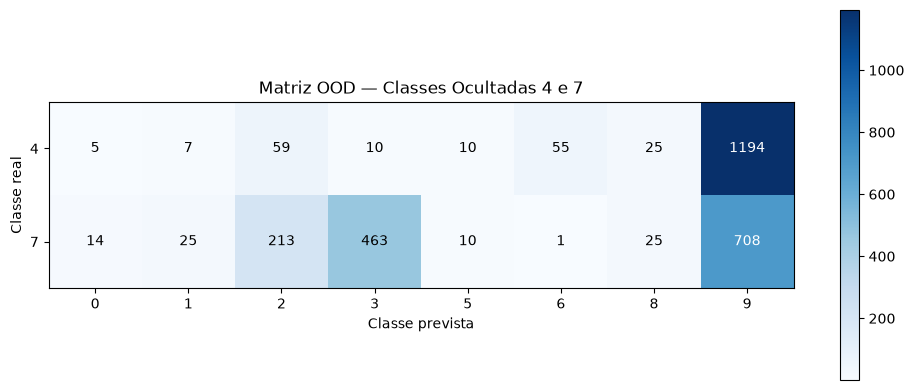

In [93]:
plotar_matriz_ood(
    matriz_ood,
    classes_reais=classes_ocultas,
    classes_previstas=classes_conhecidas,
    titulo="Matriz OOD — Classes Ocultadas 4 e 7"
)

plt.savefig(
    "../outputs/confusion_matrices/matriz_ood_classes_ocultadas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretação das previsões das classes ocultadas

A matriz evidencia que, ao receber os dígitos ocultados, a MLP foi obrigada a associá-los a alguma das oito classes conhecidas.

Entre as **1.365 imagens do dígito 4**, **1.194 foram classificadas como 9**, correspondendo a aproximadamente **87,47%** das amostras dessa classe.

Para o dígito **7**, o comportamento foi mais distribuído: das **1.459 imagens**, **708 foram classificadas como 9 (48,53%)**, **463 como 3 (31,73%)** e **213 como 2 (14,60%)**.

O resultado mostra que o modelo não possui um mecanismo para indicar que uma entrada pertence a uma classe desconhecida. Em vez disso, ele procura a classe conhecida que considera mais semelhante aos padrões aprendidos durante o treinamento.

In [53]:
# Analisa o nível de confiança das previsões sobre as classes ocultadas

probabilidades_ood = mlp_restrita.predict_proba(X_teste_ood)

# Maior probabilidade atribuída pelo modelo para cada imagem OOD
confianca_maxima_ood = probabilidades_ood.max(axis=1)

total_ood = len(confianca_maxima_ood)

acima_90 = np.sum(confianca_maxima_ood >= 0.90)
acima_99 = np.sum(confianca_maxima_ood >= 0.99)

resumo_confianca_ood = pd.DataFrame({
    "O que aconteceu": [
        "Em média, o modelo ficou confiante nas respostas",
        "Menor confiança encontrada",
        "Maior confiança encontrada",
        "Imagens desconhecidas com mais de 90% de confiança",
        "Imagens desconhecidas com mais de 99% de confiança"
    ],
    "Resultado": [
        f"{confianca_maxima_ood.mean() * 100:.2f}%",
        f"{confianca_maxima_ood.min() * 100:.2f}%",
        f"{confianca_maxima_ood.max() * 100:.2f}%",
        f"{acima_90} de {total_ood} imagens ({acima_90 / total_ood * 100:.2f}%)",
        f"{acima_99} de {total_ood} imagens ({acima_99 / total_ood * 100:.2f}%)"
    ]
})

resumo_confianca_ood

,O que aconteceu,Resultado
0,"Em média, o modelo ficou confiante nas respostas",91.30%
1,Menor confiança encontrada,29.56%
2,Maior confiança encontrada,100.00%
3,Imagens desconhecidas com mais de 90% de confi...,2089 de 2824 imagens (73.97%)
4,Imagens desconhecidas com mais de 99% de confi...,1535 de 2824 imagens (54.36%)


In [89]:
# Registra os principais indicadores do teste OOD para acompanhar o nível de confiança do modelo diante de classes desconhecidas.
logger.info(
    "Teste OOD concluído | amostras=%d | "
    "confianca_media=%.2f%% | acima_90=%.2f%% | acima_99=%.2f%%",
    len(y_teste_ood),
    confianca_maxima_ood.mean() * 100,
    (confianca_maxima_ood >= 0.90).mean() * 100,
    (confianca_maxima_ood >= 0.99).mean() * 100
)

2026-09-13 16:31:24 | INFO | Teste OOD concluído | amostras=2824 | confianca_media=91.30% | acima_90=73.97% | acima_99=54.36%


### Interpretação da falsa certeza

Mesmo sem ter sido treinado com os dígitos **4 e 7**, o modelo continuou classificando essas imagens como se pertencessem a alguma das classes conhecidas.

Em média, ele apresentou **91,30% de confiança** nas respostas. Além disso, em **2.089 de 2.824 imagens (73,97%)**, a confiança foi superior a **90%**. Em **1.535 imagens (54,36%)**, a confiança ultrapassou **99%**.

Isso significa que o modelo pode estar **muito confiante mesmo quando está errado**.

Esse comportamento é chamado de **falsa certeza (overconfidence)**. Em uma aplicação real, isso representa um risco porque uma resposta com 99% ou 100% de confiança pode parecer extremamente segura para o usuário, mesmo quando o modelo está diante de uma situação que nunca aprendeu a reconhecer.

A MLP utilizada é um classificador de conjunto fechado (closed-set classifier): ela não possui uma classe “desconhecida” nem um mecanismo explícito de rejeição. Portanto, ao receber os dígitos ocultados, necessariamente atribui cada entrada a uma das classes conhecidas. Em uma aplicação real, a identificação de entradas desconhecidas exigiria a implementação adicional de um mecanismo de rejeição ou de técnicas específicas de detecção OOD.

## Fase 5.3 — Inferência com Imagens Manuscritas Próprias

Para avaliar a capacidade de generalização do melhor modelo em dados externos ao MNIST, foram selecionadas cinco imagens do dígito **4**, obtidas por diferentes formas de aquisição.

As amostras incluem desenho digital, desenho à mão livre em ambiente computacional, manuscrito fotografado, manuscrito digitalizado e uma segunda caligrafia manuscrita.

Antes da inferência, todas as imagens passam pelo mesmo pipeline de pré-processamento, sendo convertidas para escala de cinza, adequadas ao padrão de contraste do MNIST, recortadas pela região de interesse, redimensionadas e centralizadas em uma matriz de **28 × 28 pixels**, com valores normalizados no intervalo **[0, 1]**.

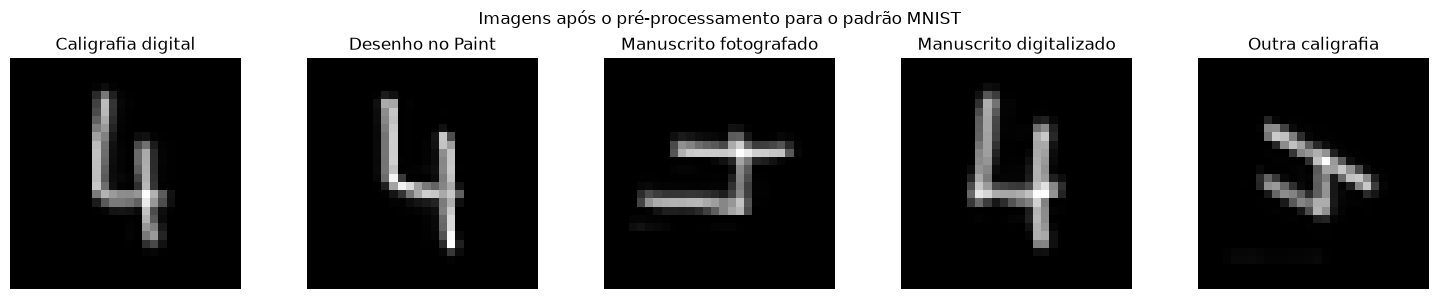

In [69]:
# Imagens externas utilizadas para avaliar a generalização do modelo
imagens_proprias = {
    "Caligrafia digital": "../data/imagens_proprias/CaligrafiaDigital.jpg",
    "Desenho no Paint": "../data/imagens_proprias/Desenho-a-mao-livre-Paint.jpg",
    "Manuscrito fotografado": "../data/imagens_proprias/Manuscrito1.jpg",
    "Manuscrito digitalizado": "../data/imagens_proprias/Manuscrito1_digitalizado.jpg",
    "Outra caligrafia": "../data/imagens_proprias/Manuscrito2.jpg"
}

imagens_processadas = {}

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, (nome, caminho) in zip(axes, imagens_proprias.items()):
    imagem_processada = preprocessar_imagem_propria(caminho)
    imagens_processadas[nome] = imagem_processada

    ax.imshow(imagem_processada, cmap="gray")
    ax.set_title(nome)
    ax.axis("off")

plt.suptitle("Imagens após o pré-processamento para o padrão MNIST")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/imagens_preprocessadas_fase5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Predição das imagens externas

Após o pré-processamento, as cinco imagens foram submetidas ao modelo MLP que apresentou o melhor desempenho no conjunto de teste na Fase 4.

Todas representam o dígito real **4**, permitindo comparar o comportamento do mesmo classificador diante de diferentes formas de aquisição e estilos de escrita. Além da classe prevista, será analisada a probabilidade atribuída pelo modelo a cada uma das dez classes.

In [77]:
# Realiza a inferência das cinco imagens com a MLP vencedora da Fase 4

resultados_imagens = []
probabilidades_imagens = {}

for nome, imagem in imagens_processadas.items():

    # A MLP recebe cada imagem 28x28 como um vetor com 784 atributos
    entrada = imagem.reshape(1, -1)

    probabilidades = mlp_2.predict_proba(entrada)[0]
    probabilidades_imagens[nome] = probabilidades
    indice_maior_probabilidade = np.argmax(probabilidades)

    classe_prevista = mlp_2.classes_[indice_maior_probabilidade]
    confianca = probabilidades[indice_maior_probabilidade]

    resultados_imagens.append({
        "Amostra": nome,
        "Valor real": 4,
        "Previsão": int(classe_prevista),
        "Confiança": confianca,
        "Acertou": "Sim" if classe_prevista == 4 else "Não"
    })

tabela_resultados = pd.DataFrame(resultados_imagens)

tabela_exibicao = tabela_resultados.copy()
tabela_exibicao["Confiança"] = tabela_exibicao["Confiança"].map(
    lambda valor: f"{valor:.2%}"
)

# Salva os resultados numéricos da inferência com imagens externas
tabela_resultados.to_csv(
    "../outputs/metrics/resultados_imagens_externas.csv",
    index=False
)


tabela_exibicao

,Amostra,Valor real,Previsão,Confiança,Acertou
0,Caligrafia digital,4,4,67.59%,Sim
1,Desenho no Paint,4,4,99.28%,Sim
2,Manuscrito fotografado,4,5,37.95%,Não
3,Manuscrito digitalizado,4,4,96.02%,Sim
4,Outra caligrafia,4,4,40.11%,Sim


In [88]:
# Registra o resultado da inferência externa para documentar a capacidade de generalização do modelo em imagens reais.
logger.info(
    "Inferência externa concluída | amostras=%d | acertos=%d",
    len(tabela_resultados),
    (tabela_resultados["Previsão"] == tabela_resultados["Valor real"]).sum()
)

2026-09-13 16:30:24 | INFO | Inferência externa concluída | amostras=5 | acertos=4


### Distribuição das probabilidades por imagem

Para complementar a classe prevista, são apresentadas as probabilidades atribuídas pela MLP a cada dígito de **0 a 9**. Essa visualização permite observar não apenas se o modelo acertou, mas também o seu nível de confiança e quais classes competiram pela decisão final.

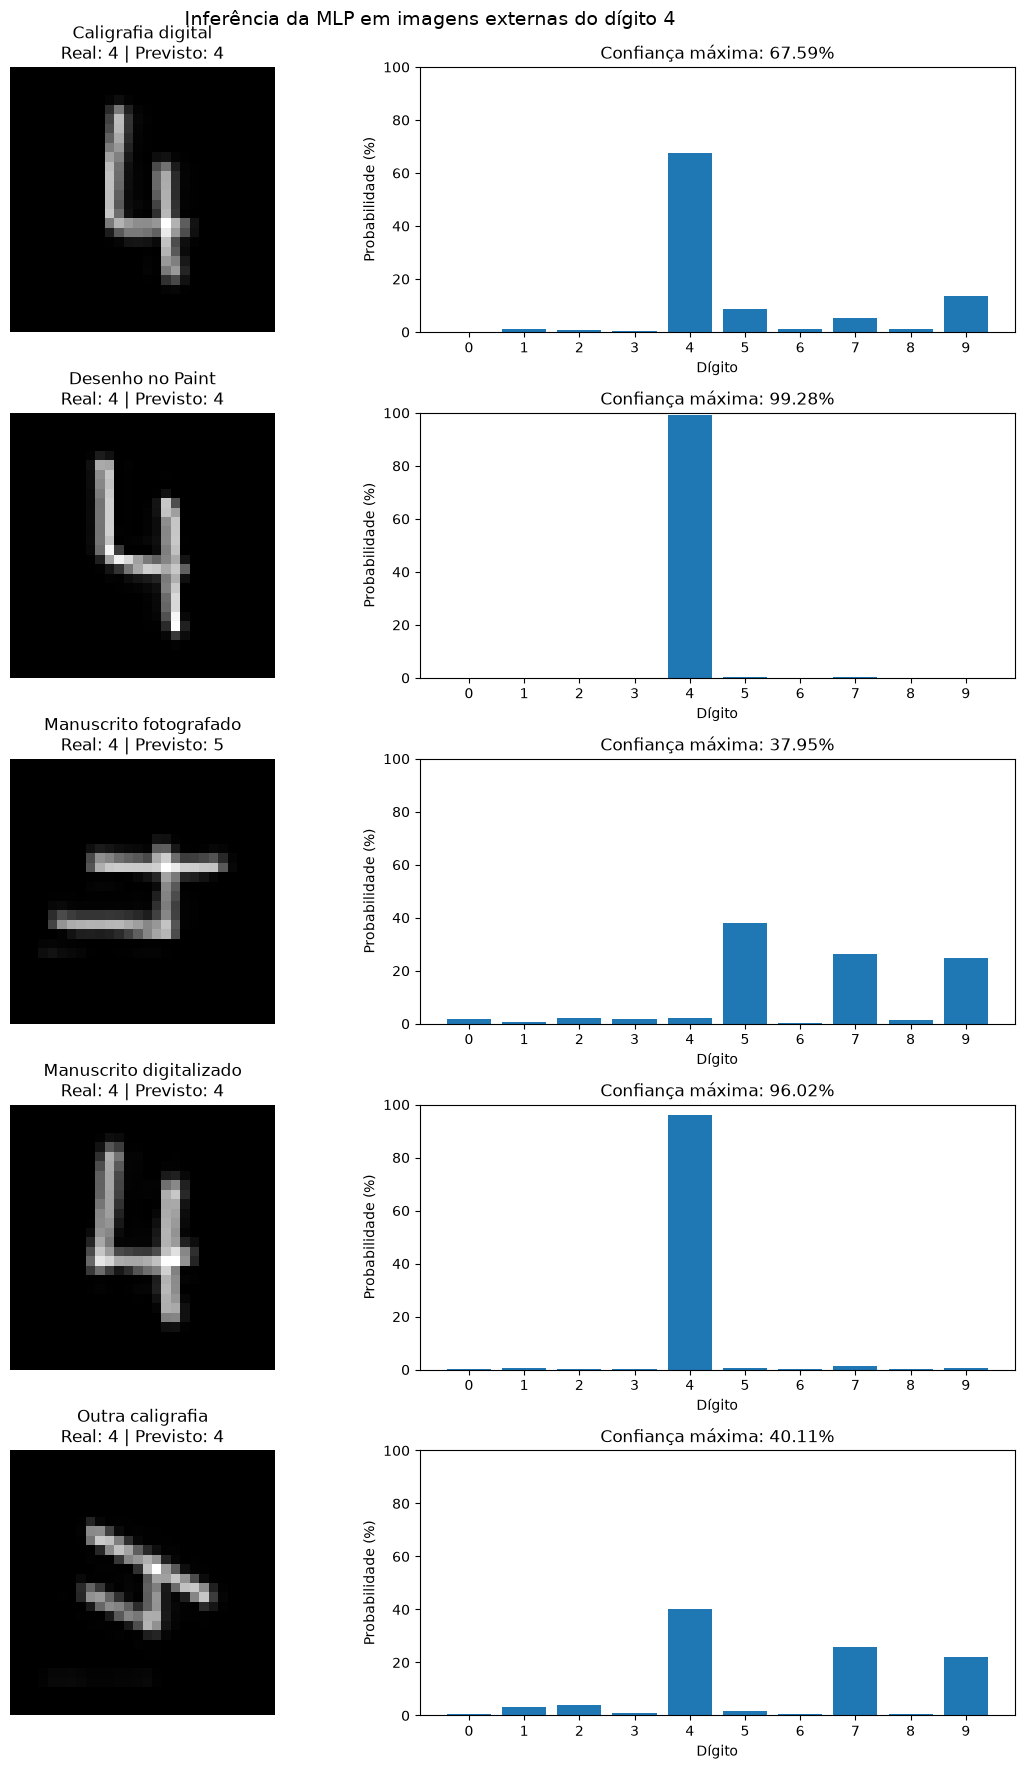

In [70]:
# Exibe cada imagem processada ao lado das probabilidades previstas pela MLP

fig, axes = plt.subplots(
    len(imagens_processadas),
    2,
    figsize=(12, 18)
)

for linha, (nome, imagem) in enumerate(imagens_processadas.items()):

    probabilidades = probabilidades_imagens[nome]

    indice_previsto = np.argmax(probabilidades)
    classe_prevista = mlp_2.classes_[indice_previsto]
    confianca = probabilidades[indice_previsto]

    # Imagem efetivamente fornecida ao modelo
    axes[linha, 0].imshow(
        imagem,
        cmap="gray"
    )

    axes[linha, 0].set_title(
        f"{nome}\nReal: 4 | Previsto: {classe_prevista}"
    )

    axes[linha, 0].axis("off")

    # Probabilidades atribuídas às dez classes
    axes[linha, 1].bar(
        mlp_2.classes_,
        probabilidades * 100
    )

    axes[linha, 1].set_title(
        f"Confiança máxima: {confianca:.2%}"
    )

    axes[linha, 1].set_xlabel("Dígito")
    axes[linha, 1].set_ylabel("Probabilidade (%)")
    axes[linha, 1].set_xticks(range(10))
    axes[linha, 1].set_ylim(0, 100)

plt.suptitle(
    "Inferência da MLP em imagens externas do dígito 4",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/probabilidades_imagens_externas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretação dos resultados — Inferência com imagens externas

O experimento avaliou a capacidade de generalização da MLP utilizando cinco imagens externas do dígito **4**, produzidas por diferentes formas de aquisição e estilos de escrita. O dígito 4 foi escolhido por ter apresentado, nas etapas anteriores, um padrão relevante de confusão com outras classes.

Das cinco amostras avaliadas, **quatro foram classificadas corretamente como 4**. Entretanto, os níveis de confiança variaram consideravelmente de acordo com as características da entrada.

O **desenho no Paint** apresentou a maior confiança entre as amostras, com **99,28%**, seguido pelo **manuscrito digitalizado**, com **96,02%**. Essas imagens apresentam características mais próximas do padrão visual utilizado pelo MNIST após o pré-processamento, com maior uniformidade de fundo e contraste.

A **caligrafia digital** também foi corretamente classificada como 4, porém com confiança de **67,59%**. A amostra de **outra caligrafia** foi reconhecida corretamente com apenas **40,11%**, indicando maior incerteza do classificador diante da variação no formato do dígito.

O **manuscrito fotografado** foi a única classificação incorreta: o valor real 4 foi previsto como **5**, com confiança de **37,95%**. A inspeção da imagem após o pré-processamento mostra que as condições de aquisição e transformação alteraram características importantes do traço, tornando a representação final mais distante das amostras típicas do MNIST.

Esses resultados evidenciam o fenômeno de **domain shift**: embora o modelo apresente alto desempenho em dados provenientes da mesma distribuição utilizada em seu desenvolvimento, imagens externas podem apresentar diferenças de iluminação, contraste, espessura do traço, geometria e forma de aquisição.

Neste pequeno experimento externo, ocorreram **4 acertos em 5 imagens (80%)**. Esse percentual não deve ser interpretado como uma nova estimativa formal da acurácia do modelo, pois o conjunto contém apenas cinco amostras e foi utilizado para análise qualitativa de generalização.

Em conjunto com o experimento de classes ocultadas, os resultados mostram duas limitações importantes. Na avaliação OOD, o modelo demonstrou **falsa certeza**, atribuindo probabilidades muito elevadas a classes conhecidas mesmo diante de dígitos que nunca haviam participado do treinamento. Já nas imagens manuscritas externas, observou-se sensibilidade às diferenças entre o domínio do MNIST e entradas produzidas em condições reais.

Portanto, uma elevada acurácia no conjunto de teste não garante, isoladamente, robustez em situações reais. Modelos aplicados em produção devem ter seu desempenho monitorado e, quando forem identificadas mudanças relevantes nos dados ou perda de desempenho, podem exigir atualização ou retreinamento com dados representativos do novo cenário.

## Conclusão Geral

O projeto permitiu desenvolver e avaliar um pipeline completo de classificação multiclasse utilizando o dataset MNIST, desde a análise exploratória e preparação dos dados até o treinamento, comparação e avaliação de diferentes modelos de Machine Learning.

Entre Random Forest, SVM e MLP, a **MLP apresentou o melhor desempenho global no conjunto de teste, com 97,66% de acurácia**, sendo selecionada como o modelo principal para os experimentos posteriores. A análise das matrizes de confusão também mostrou que um bom resultado global não elimina erros específicos entre determinadas classes.

Os experimentos de robustez ampliaram essa avaliação. Com a ocultação das classes **4 e 7**, observou-se que o classificador continuou atribuindo as entradas a classes conhecidas, inclusive com níveis elevados de confiança, evidenciando o problema de **falsa certeza (overconfidence)** diante de dados fora da distribuição de treinamento.

Na inferência com imagens externas do dígito **4**, obtidas por diferentes formas de aquisição e estilos de escrita, ocorreram **4 acertos em 5 amostras**. As diferenças observadas entre imagens digitais, digitalizadas e fotografadas evidenciaram o impacto do **domain shift** e a importância do pré-processamento para aproximar dados reais do padrão utilizado durante o treinamento.

Assim, os resultados demonstram que a avaliação de um modelo não deve se limitar a uma única métrica de desempenho. Matrizes de confusão, análise por classe, testes com dados desconhecidos, probabilidades de saída e experimentos com entradas externas fornecem uma visão mais completa sobre sua capacidade de generalização e suas limitações.

Em aplicações reais, modelos preditivos devem ser monitorados após a implantação e reavaliados quando houver mudanças relevantes na distribuição dos dados ou perda de desempenho, podendo ser necessário atualizar os dados de treinamento ou realizar novo treinamento.